# Implementación de CNN Baseline (Mel-Spectrograms) para Clasificación de Comandos de Voz
Este notebook implementa la arquitectura base descrita en el plan, utilizando PyTorch para cargar datos en `.npy`, transformarlos dinámicamente en Mel-Espectrogramas en la GPU, y entrenar un modelo CNN clásico.


In [ ]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q kagglehub torch torchaudio pandas numpy matplotlib scikit-learn librosa
    import kagglehub
    import os
    data_path = kagglehub.competition_download("voice-commands-classification-2026")
    TRAIN_DATA_PATH = os.path.join(data_path, 'train')
else:
    TRAIN_DATA_PATH = './data/train'

print(f"IN_COLAB: {IN_COLAB}")
print(f"Data path: {TRAIN_DATA_PATH}")

In [2]:
!pip install numpy pandas matplotlib scikit-learn librosa soundfile audioread numba
!pip install torch torchaudio

In [2]:
!pip install numpy pandas matplotlib scikit-learn librosa soundfile audioread numba
!pip install torch torchaudio

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 4.4 MB/s  0:01:376m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 7.9 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 7.8 MB/s  0:01:016m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 8.4 MB/s  0:00:016m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 8.5 MB/s  0:00:106m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 2.5 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 7.2 MB/s  0:01:126m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 9.3 MB/s  0:00:206m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 1.1 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 6.8 MB/s  0:00:096m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# Comprobar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## Configuración e Hiperparámetros


In [16]:
# Hiperparametros y configuracion
CONFIG = {
    'sample_rate': 16000,
    'duration': 1.0,
    'n_mels': 64,
    'n_fft': 1024,
    'hop_length': 256,
    'batch_size': 64,
    'epochs': 12,
    'lr': 1e-3,
    'patience': 4,
    # En Jupyter, usar workers > 0 puede causar BrokenPipeError en algunos entornos.
    'num_workers': 0,
    'val_size': 0.2,
    'seed': 42,
    'train_metadata_csv': 'train_metadata.csv',
    'train_audio_dir': (TRAIN_DATA_PATH + '/train') if 'TRAIN_DATA_PATH' in dir() else 'data/train',
}
CONFIG['max_samples'] = int(CONFIG['sample_rate'] * CONFIG['duration'])

np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
print(CONFIG)

{'sample_rate': 16000, 'duration': 1.0, 'n_mels': 64, 'n_fft': 1024, 'hop_length': 256, 'batch_size': 64, 'epochs': 12, 'lr': 0.001, 'patience': 4, 'num_workers': 0, 'val_size': 0.2, 'seed': 42, 'train_metadata_csv': 'train_metadata.csv', 'metadata_csv': 'data/train/train/train/metadata.csv', 'train_audio_dir': 'data/train/train/train', 'max_samples': 16000}


## 1. Extracción y Carga de Datos (Data Ingestion)
La clase `VoiceCommandsDataset` carga arreglos `.npy` y realiza _zero-padding_ y cortes para garantizar longitudes uniformes de un segundo.


In [14]:
class VoiceCommandsDataset(Dataset):
    def __init__(self, df, audio_dir, max_samples=16000):
        self.df = df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.max_samples = max_samples

    def __len__(self):
        return len(self.df)

    def _normalize_length(self, audio):
        if audio.shape[0] > self.max_samples:
            return audio[:self.max_samples]
        if audio.shape[0] < self.max_samples:
            padding = self.max_samples - audio.shape[0]
            return np.pad(audio, (0, padding), mode='constant')
        return audio

    def _load_audio_array(self, file_name):
        file_path = self.audio_dir / file_name
        arr = np.load(file_path, allow_pickle=False)
        if isinstance(arr, np.lib.npyio.NpzFile):
            key = 'audio' if 'audio' in arr.files else arr.files[0]
            arr = arr[key]
        arr = np.asarray(arr).reshape(-1).astype(np.float32)
        return arr

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio = self._load_audio_array(row['filename'])
        audio = self._normalize_length(audio)
        label = int(row['label_id'])
        return torch.tensor(audio, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


# Carga metadata enriquecida con labels
train_df = pd.read_csv(CONFIG['train_metadata_csv'])

# Fallback: si train_metadata.csv no trae label, enriquecer desde metadata.csv
if 'label' not in train_df.columns or train_df['label'].isna().any():
    meta_df = pd.read_csv(os.path.join(CONFIG['train_audio_dir'], 'metadata.csv'), usecols=['file_name', 'label'])
    meta_df = meta_df.rename(columns={'file_name': 'filename'})
    if 'filename' not in train_df.columns:
        train_df['filename'] = train_df['file_path'].apply(lambda p: Path(p).name)
    train_df = train_df.drop(columns=['label'], errors='ignore').merge(meta_df, on='filename', how='left')

train_df = train_df.dropna(subset=['label']).copy()
train_df['label'] = train_df['label'].astype(str)

label_encoder = LabelEncoder()
train_df['label_id'] = label_encoder.fit_transform(train_df['label'])
num_classes = len(label_encoder.classes_)

train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=CONFIG['val_size'],
    random_state=CONFIG['seed'],
    stratify=train_df['label_id']
)

train_dataset = VoiceCommandsDataset(
    train_split_df,
    audio_dir=CONFIG['train_audio_dir'],
    max_samples=CONFIG['max_samples']
)
val_dataset = VoiceCommandsDataset(
    val_split_df,
    audio_dir=CONFIG['train_audio_dir'],
    max_samples=CONFIG['max_samples']
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=torch.cuda.is_available()
)

print(f"Total muestras: {len(train_df)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"Numero de clases: {num_classes}")
print("Primeras clases:", list(label_encoder.classes_[:10]))

Total muestras: 95246
Train: 76196 | Val: 19050
Numero de clases: 35
Primeras clases: ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward']


## 2. Preprocesamiento: Conversión a Espectrogramas
Cálculo logarítmico del Mel-Espectrograma on-the-fly usando `torchaudio`. Incluye la estandarización por instancia.


In [17]:
class AudioToMelSpectrogram(nn.Module):
    def __init__(self, sample_rate=16000, n_fft=1024, hop_length=512, n_mels=64):
        super().__init__()
        self.mel_spec = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )
        self.amplitude_to_db = T.AmplitudeToDB()

    def forward(self, x):
        # x.shape esperado: (batch, time)
        # torchaudio espera shape: (batch, channels, time) en algunas versiones, o (batch, time)
        if x.dim() == 1:
            x = x.unsqueeze(0) # Añadir dim de canal para un solo audio
        
        mel = self.mel_spec(x) # (batch, n_mels, time) o semejante
        mel_db = self.amplitude_to_db(mel)
        
        # Normalización: (Media 0, Varianza 1) por instancia
        # Esto ayuda mucho a la convergencia
        mean = mel_db.mean(dim=[-2, -1], keepdim=True)
        std = mel_db.std(dim=[-2, -1], keepdim=True)
        mel_norm = (mel_db - mean) / (std + 1e-8)
        
        return mel_norm

# Instanciar transformación y mover a device
audio_transform = AudioToMelSpectrogram(
    sample_rate=CONFIG['sample_rate'],
    n_fft=CONFIG['n_fft'],
    hop_length=CONFIG['hop_length'],
    n_mels=CONFIG['n_mels']
).to(device)


## 3. Verificación Manual (Sanity Check)
Visualizar la extracción de features acústicos para comprobar que no hay ruidos aleatorios invisibles.


Forma waveform: (16000,)
Forma mel: (1, 64, 63)
Etiqueta ejemplo: up


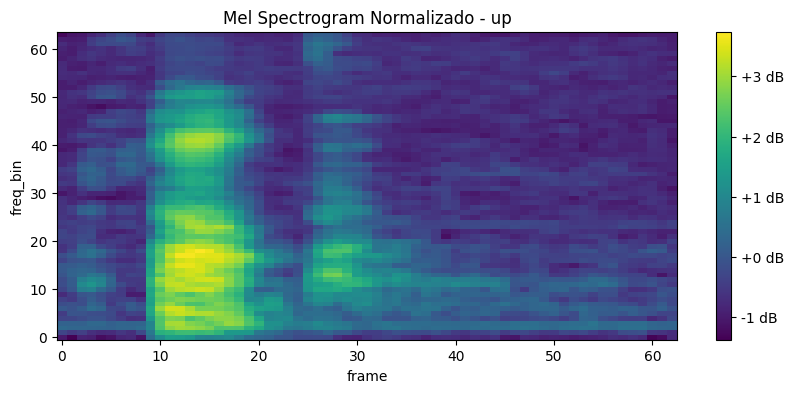

In [18]:
def plot_spectrogram(spec, title=None, ylabel='freq_bin', aspect='auto', xmax=None):
    fig, ax = plt.subplots(figsize=(10, 4))
    if title:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('frame')
    im = ax.imshow(spec, origin='lower', aspect=aspect)
    if xmax:
        ax.set_xlim((0, xmax))
    fig.colorbar(im, ax=ax, format='%+2.0f dB')
    plt.show()

# Obtener una muestra real del split de entrenamiento
sample_audio, sample_label = train_dataset[0]
sample_class = label_encoder.inverse_transform([sample_label.item()])[0]

# Aplicamos la transformacion (batch de tamano 1)
sample_mel = audio_transform(sample_audio.unsqueeze(0).to(device))
sample_mel_np = sample_mel.squeeze().cpu().numpy()

print(f"Forma waveform: {tuple(sample_audio.shape)}")
print(f"Forma mel: {tuple(sample_mel.shape)}")
print(f"Etiqueta ejemplo: {sample_class}")

plot_spectrogram(sample_mel_np, title=f"Mel Spectrogram Normalizado - {sample_class}")

## 4. Arquitectura CNN (Clasificador)
Arquitectura CNN 2D sencilla con `AdaptiveAvgPool2d` para una transición limpia a las capas densas independientemente de ligeras variaciones.


In [19]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Entrada esperada: (batch, 1, n_mels, frames)
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.features(x)
        x = self.classifier(x)
        return x


model = BaselineCNN(num_classes=num_classes).to(device)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.2, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=35, bias=True)
  )
)


## 5. Ciclo de Entrenamiento
Definición de función de pérdida y optimización con Adam, más parada temprana (Early Stopping).


In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])

best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

In [25]:
from torch.utils.data import TensorDataset
import time

# 1) Precomputo de Mel una sola vez para evitar costo repetido por batch/epoca
def build_mel_feature_loader(wave_loader, transform, device, batch_size, shuffle):
    mel_batches = []
    label_batches = []

    transform.eval()
    start_t = time.time()
    with torch.inference_mode():
        for audios, labels in wave_loader:
            audios = audios.to(device, non_blocking=True)
            mels = transform(audios)
            # Guardar en CPU para liberar GPU y reutilizar durante todas las epocas.
            mel_batches.append(mels.cpu().to(torch.float16))
            label_batches.append(labels.cpu())

    mel_tensor = torch.cat(mel_batches, dim=0)
    label_tensor = torch.cat(label_batches, dim=0).long()
    ds = TensorDataset(mel_tensor, label_tensor)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    elapsed = time.time() - start_t
    print(f"Precompute done | samples={len(ds)} | time={elapsed:.1f}s")
    return dl

print('Precomputando Mel train...')
train_mel_loader = build_mel_feature_loader(
    train_loader,
    audio_transform,
    device=device,
    batch_size=CONFIG['batch_size'],
    shuffle=True
    )

print('Precomputando Mel val...')
val_mel_loader = build_mel_feature_loader(
    val_loader,
    audio_transform,
    device=device,
    batch_size=CONFIG['batch_size'],
    shuffle=False
    )

# 2) Entrenamiento sobre Mel precomputado + AMP en GPU
epochs = CONFIG['epochs']
use_amp = device.type == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for mels, labels in train_mel_loader:
        mels = mels.to(device, non_blocking=True, dtype=torch.float32)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            outputs = model(mels)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum += loss.item() * mels.size(0)
        preds = outputs.argmax(dim=1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    epoch_train_loss = train_loss_sum / train_total
    epoch_train_acc = train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # --- VAL ---
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.inference_mode():
        for mels, labels in val_mel_loader:
            mels = mels.to(device, non_blocking=True, dtype=torch.float32)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                outputs = model(mels)
                loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * mels.size(0)
            preds = outputs.argmax(dim=1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss_sum / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    print(
        f"Epoch {epoch + 1:02d}/{epochs:02d} | "
        f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc * 100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc * 100:.2f}%"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_cnn_baseline.pth')
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f"Early stopping accionado en epoca {epoch + 1}")
            break

# Cargar mejor modelo y obtener predicciones para matriz de confusion
model.load_state_dict(torch.load('best_cnn_baseline.pth', map_location=device))
model.eval()

y_true = []
y_pred = []

with torch.inference_mode():
    for mels, labels in val_mel_loader:
        mels = mels.to(device, non_blocking=True, dtype=torch.float32)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(mels)
        preds = logits.argmax(dim=1).cpu().numpy()

        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())

val_acc_final = (np.array(y_true) == np.array(y_pred)).mean()
cm = confusion_matrix(y_true, y_pred)

print(f"\nAccuracy final en validacion: {val_acc_final * 100:.2f}%")

Precomputando Mel train...
Precompute done | samples=76196 | time=886.9s
Precomputando Mel val...
Precompute done | samples=19050 | time=297.7s
Epoch 01/12 | Train Loss: 1.8555 Acc: 43.96% | Val Loss: 1.4486 Acc: 57.04%
Epoch 02/12 | Train Loss: 1.6210 Acc: 51.05% | Val Loss: 1.1759 Acc: 66.10%
Epoch 03/12 | Train Loss: 1.4260 Acc: 56.92% | Val Loss: 1.0230 Acc: 70.43%
Epoch 04/12 | Train Loss: 1.3017 Acc: 60.85% | Val Loss: 0.8977 Acc: 74.02%
Epoch 05/12 | Train Loss: 1.1963 Acc: 63.82% | Val Loss: 0.8338 Acc: 75.70%
Epoch 06/12 | Train Loss: 1.1112 Acc: 66.53% | Val Loss: 0.7608 Acc: 77.78%


KeyboardInterrupt: 

## 6. Curvas de Aprendizaje y Matriz de Confusión
Visualización de pérdidas, exactitud y desempeño por clase en validación.

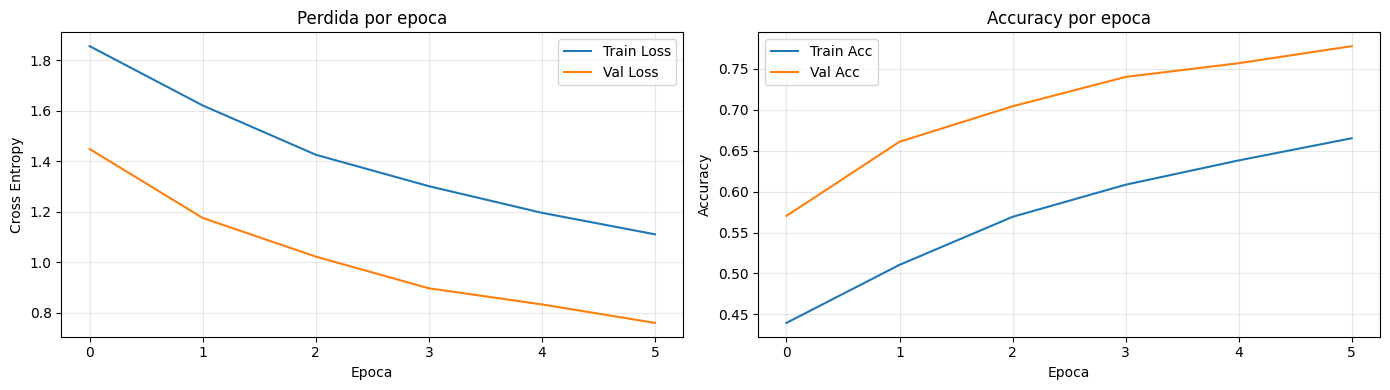

NameError: name 'cm' is not defined

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Perdida por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross Entropy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_title('Accuracy por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Matriz de confusion normalizada por fila para facilitar lectura
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation='nearest', aspect='auto')
plt.title('Matriz de confusion (normalizada)')
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel('Prediccion')
plt.ylabel('Etiqueta real')
plt.tight_layout()
plt.show()

print('Reporte de clasificacion (validacion):')
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))